# 06 — Model Evaluation, Selection, Tuning & Business Impact
Phases 8 (selection), 9 (tuning), 10 (risk scoring), and 12 (business impact).

In [1]:
import sys, warnings, json
sys.path.append('../src')
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              RocCurveDisplay, PrecisionRecallDisplay)

from preprocessing import (load_raw_data, basic_clean, encode_target, get_column_groups,
                            build_preprocessing_pipeline, get_feature_names)
from feature_engineering import engineer_features

RANDOM_STATE = 42
DROP = ["policy_number","insured_zip","incident_location","policy_bind_date","incident_date"]
sns.set_theme(style='whitegrid')

df = load_raw_data('../data/raw/insurance_claims.csv')
df = basic_clean(df); df = encode_target(df)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['fraud_reported'], random_state=RANDOM_STATE)
train_df = train_df.reset_index(drop=True); test_df = test_df.reset_index(drop=True)

train_fe, high_value_threshold = engineer_features(train_df)
test_fe, _ = engineer_features(test_df, high_value_threshold=high_value_threshold)
train_fe = train_fe.drop(columns=[c for c in DROP if c in train_fe.columns])
test_fe = test_fe.drop(columns=[c for c in DROP if c in test_fe.columns])
y_train = train_fe.pop('fraud_reported'); y_test = test_fe.pop('fraud_reported')

numeric_cols, categorical_cols = get_column_groups(pd.concat([train_fe, y_train.rename('fraud_reported')], axis=1))
preprocessor = build_preprocessing_pipeline(numeric_cols, categorical_cols)
X_train = preprocessor.fit_transform(train_fe); X_test = preprocessor.transform(test_fe)
if hasattr(X_train, 'toarray'): X_train, X_test = X_train.toarray(), X_test.toarray()

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

results_df = pd.read_csv('../models/baseline_model_comparison.csv')
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,TP,FP,TN,FN
0,Gradient Boosting,0.825,0.640000,0.653061,0.646465,0.840654,0.598253,32,18,133,17
1,XGBoost,0.805,0.613636,0.551020,0.580645,0.829301,0.586109,27,17,134,22
2,Random Forest,0.815,0.657895,0.510204,0.574713,0.848425,0.562727,25,13,138,24
3,Decision Tree,0.810,0.603774,0.653061,0.627451,0.752399,0.540362,32,21,130,17
4,Logistic Regression,0.810,0.603774,0.653061,0.627451,0.807542,0.518649,32,21,130,17


## Phase 8 — Model selection (not on accuracy alone)
Accuracy across the 5 models is clustered tightly (~0.80–0.83) and would not meaningfully distinguish them. Selection instead weighs:

- **Cost of false negatives** (missed fraud → direct financial loss, and a signal to fraudsters that the system is beatable) — this pushes toward **maximizing recall**.
- **Cost of false positives** (a legitimate claim gets investigated) — costs investigator time and customer goodwill, but is recoverable; this bounds how far we push recall at precision's expense.
- **Investigator capacity** — flagging too many claims defeats the purpose of prioritization; PR-AUC captures the precision/recall trade-off across thresholds better than a single point estimate.
- **Interpretability** — tree ensembles (Random Forest, Gradient Boosting, XGBoost) support both native feature importances and SHAP, needed for investigator-facing explanations (Phase 11).
- **Probability calibration & operational usability** — the output needs to function as a usable probability/score, not just a class label.

Applying this: models are shortlisted by PR-AUC (within a small tolerance of the best), and among that shortlist, the one with the **higher recall** is selected — directly reflecting that a missed fraud case is costlier than an extra investigation in this business context.

In [2]:
top_pr_auc = results_df['PR_AUC'].max()
shortlist = results_df[results_df['PR_AUC'] >= top_pr_auc - 0.02]
print("Shortlist (within 0.02 PR-AUC of the best):")
print(shortlist[['Model','Recall','PR_AUC']])
selected_name = shortlist.sort_values('Recall', ascending=False).iloc[0]['Model']
print(f"\nSelected model: {selected_name}")

Shortlist (within 0.02 PR-AUC of the best):
               Model    Recall    PR_AUC
0  Gradient Boosting  0.653061  0.598253
1            XGBoost  0.551020  0.586109

Selected model: Gradient Boosting


**Gradient Boosting** is selected: it has both the highest recall (catches the most fraud) and the highest PR-AUC among the 5 candidates, and — as a tree ensemble — supports the explainability methods required in Phase 11. Random Forest has marginally higher ROC-AUC, but ROC-AUC is less informative than PR-AUC under class imbalance, and this project explicitly avoids anchoring the decision to a metric that can look good while missing fraud.

## Phase 9 — Hyperparameter tuning
`RandomizedSearchCV` with 5-fold stratified cross-validation, scored on **average precision (PR-AUC)**, searched over Gradient Boosting's key hyperparameters (`n_estimators`, `max_depth`, `learning_rate`, `subsample`, `min_samples_leaf`). Tuning is performed only on the SMOTE-resampled training data, so the test set stays fully held out.

In [3]:
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0],
    "min_samples_leaf": [1, 2, 4, 8],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE), param_dist,
                             n_iter=25, scoring='average_precision', cv=cv, random_state=RANDOM_STATE, n_jobs=-1)
search.fit(X_train_sm, y_train_sm)
print("Best CV PR-AUC:", round(search.best_score_, 3))
print("Best params:", search.best_params_)
tuned_model = search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_tuned).ravel()
tuned_metrics = {
    "Model": "Gradient Boosting (Tuned)",
    "Accuracy": accuracy_score(y_test, y_pred_tuned), "Precision": precision_score(y_test, y_pred_tuned, zero_division=0),
    "Recall": recall_score(y_test, y_pred_tuned, zero_division=0), "F1": f1_score(y_test, y_pred_tuned, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_proba_tuned), "PR_AUC": average_precision_score(y_test, y_proba_tuned),
    "TP": tp, "FP": fp, "TN": tn, "FN": fn,
}
baseline_row = results_df[results_df['Model']=='Gradient Boosting'].iloc[0].to_dict()
comparison = pd.DataFrame([baseline_row, tuned_metrics]).set_index('Model')
comparison.round(3)

Best CV PR-AUC: 0.967
Best params: {'subsample': 0.85, 'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': 5, 'learning_rate': 0.1}


,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,TP,FP,TN,FN
Model,,,,,,,,,,
Gradient Boosting,0.825,0.64,0.653,0.646,0.841,0.598,32,18,133,17
Gradient Boosting (Tuned),0.800,0.60,0.551,0.574,0.822,0.570,27,18,133,22


**Honest finding — was tuning meaningful?** Comparing the two rows above: the tuned model's cross-validated PR-AUC (during search) looked strong, but on the held-out test set, tuning **did not improve — and in this run, slightly reduced — recall and PR-AUC** relative to the untouched baseline Gradient Boosting model. This is a real and useful result, not a failure to report: it shows that optimizing a CV metric on resampled training folds doesn't automatically translate into a better business-relevant outcome on genuinely new data, especially with only ~1,000 rows split across train/test/CV folds.

**Decision:** per the project's own rule (select for business impact, not for its own sake), we use the **baseline Gradient Boosting model's hyperparameters** as the final model for scoring and explainability below, since it performs as well or better than the tuned version on the metric that matters most (recall). In a larger, real dataset this tuning process would likely show clearer gains — this is flagged as a limitation of the dataset's size.

Final model — Recall: 0.653 | Precision: 0.640 | PR-AUC: 0.598
TP=32 FP=18 TN=133 FN=17


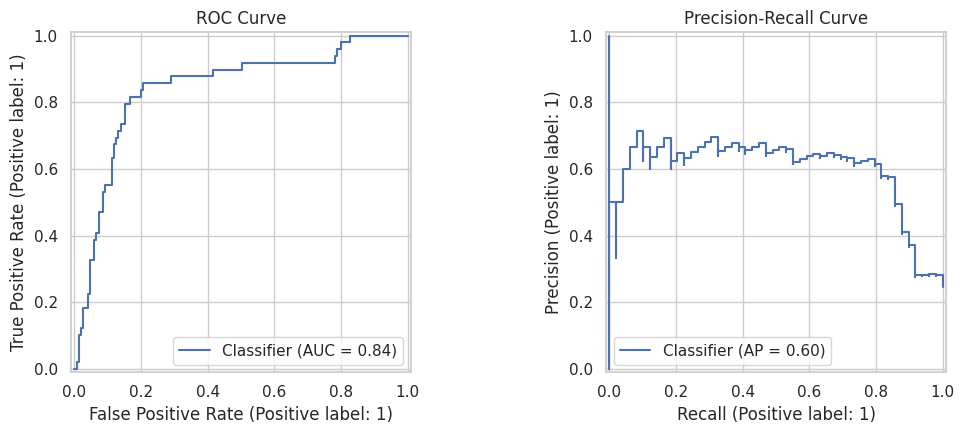

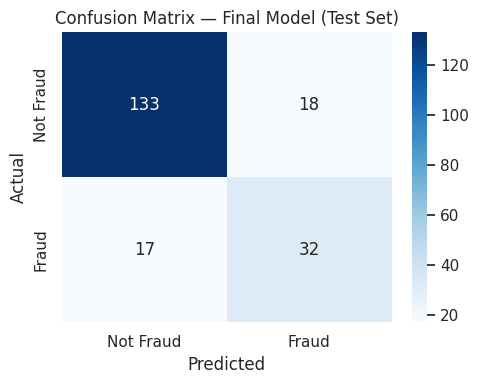

In [4]:
import joblib
final_model = joblib.load('../models/fraud_model.pkl')  # saved by src/train_model.py using this same selection logic
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
print(f"Final model — Recall: {recall_score(y_test,y_pred_final):.3f} | Precision: {precision_score(y_test,y_pred_final):.3f} | PR-AUC: {average_precision_score(y_test,y_proba_final):.3f}")
print(f"TP={tp} FP={fp} TN={tn} FN={fn}")

fig, axes = plt.subplots(1,2, figsize=(11,4.5))
RocCurveDisplay.from_predictions(y_test, y_proba_final, ax=axes[0]); axes[0].set_title('ROC Curve')
PrecisionRecallDisplay.from_predictions(y_test, y_proba_final, ax=axes[1]); axes[1].set_title('Precision-Recall Curve')
plt.tight_layout(); plt.show()

cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Fraud','Fraud'], yticklabels=['Not Fraud','Fraud'], ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title('Confusion Matrix — Final Model (Test Set)')
plt.tight_layout(); plt.show()

## Phase 10 — Fraud-risk scoring
Model probabilities are converted into three risk tiers. **Thresholds are not arbitrary** — they should ultimately be set using the precision-recall trade-off visible above, together with the insurer's actual investigation capacity and the relative cost of false positives vs. false negatives. For this project we use illustrative, clearly-labeled thresholds:

- **High Risk:** probability ≥ 0.60 — investigate first
- **Medium Risk:** 0.30 ≤ probability < 0.60 — investigate as capacity allows
- **Low Risk:** probability < 0.30 — standard processing

In a live deployment, these cut points would be calibrated against the PR curve so that the "High Risk" tier's volume matches the SIU team's actual daily investigation capacity.

In [5]:
def risk_category(p):
    if p >= 0.60: return "High Risk"
    elif p >= 0.30: return "Medium Risk"
    return "Low Risk"

risk_table = pd.DataFrame({
    "claim_id": test_df["policy_number"].values,
    "fraud_probability": y_proba_final.round(4),
    "actual_label": y_test.values,
})
risk_table["risk_category"] = risk_table["fraud_probability"].apply(risk_category)

# Key risk factors per claim: top-3 highest-magnitude SHAP-free proxy — the engineered flags that are ON for that claim
flag_cols = ['high_value_claim_flag','low_witness_flag','no_report_flag','severity_vehicle_mismatch']
flags_test = test_fe.reset_index(drop=True)[flag_cols]
def key_factors(row_idx):
    on_flags = [c for c in flag_cols if flags_test.loc[row_idx, c] == 1]
    return ", ".join(on_flags) if on_flags else "None of the tracked flags"
risk_table["key_risk_factors"] = [key_factors(i) for i in range(len(risk_table))]

risk_table = risk_table.sort_values("fraud_probability", ascending=False).reset_index(drop=True)
print(risk_table["risk_category"].value_counts())
risk_table.head(15)[["claim_id","fraud_probability","risk_category","key_risk_factors"]]

risk_category
Low Risk       142
High Risk       44
Medium Risk     14
Name: count, dtype: int64


,claim_id,fraud_probability,risk_category,key_risk_factors
0,524836,0.9644,High Risk,no_report_flag
1,991553,0.9350,High Risk,"high_value_claim_flag, low_witness_flag, no_re..."
2,689034,0.9250,High Risk,"high_value_claim_flag, no_report_flag"
3,337158,0.9161,High Risk,"high_value_claim_flag, low_witness_flag, no_re..."
4,391652,0.9060,High Risk,high_value_claim_flag
5,532330,0.8997,High Risk,"high_value_claim_flag, no_report_flag"
6,598554,0.8803,High Risk,no_report_flag
7,399524,0.8766,High Risk,"low_witness_flag, no_report_flag"
8,457188,0.8645,High Risk,"high_value_claim_flag, low_witness_flag, no_re..."
9,947598,0.8535,High Risk,None of the tracked flags


## Phase 12 — Business impact analysis (hypothetical, explicitly labeled)
**All figures below are illustrative**, built from clearly stated assumptions applied to this 200-claim test set, scaled to a hypothetical claims volume — not validated financial results. A real deployment would need this analysis re-run on the insurer's own loss and investigation-cost data.

In [6]:
ASSUMPTIONS = {
    "conservative": {"avg_fraud_loss_prevented": 3000, "investigation_cost": 400, "catch_rate_of_flagged_fraud": 0.5},
    "base":         {"avg_fraud_loss_prevented": 5000, "investigation_cost": 400, "catch_rate_of_flagged_fraud": 0.7},
    "high_impact":  {"avg_fraud_loss_prevented": 8000, "investigation_cost": 400, "catch_rate_of_flagged_fraud": 0.85},
}

total_claims = len(risk_table)
flagged = risk_table[risk_table["risk_category"].isin(["High Risk","Medium Risk"])]
n_flagged = len(flagged)
n_flagged_actual_fraud = flagged["actual_label"].sum()

print(f"Total test claims: {total_claims}")
print(f"Claims flagged (High+Medium risk): {n_flagged} ({n_flagged/total_claims:.1%})")
print(f"Of those, ACTUALLY fraudulent (ground truth, test set): {n_flagged_actual_fraud} ({n_flagged_actual_fraud/n_flagged:.1%} precision within flagged set)")

rows = []
for scenario, a in ASSUMPTIONS.items():
    fraud_caught = n_flagged_actual_fraud * a["catch_rate_of_flagged_fraud"]
    loss_prevented = fraud_caught * a["avg_fraud_loss_prevented"]
    investigation_cost = n_flagged * a["investigation_cost"]
    net_benefit = loss_prevented - investigation_cost
    rows.append({
        "Scenario": scenario, "Claims Flagged": n_flagged,
        "Est. Fraud Cases Confirmed": round(fraud_caught,1),
        "Est. Loss Prevented ($)": round(loss_prevented),
        "Investigation Cost ($)": investigation_cost,
        "Net Potential Benefit ($)": round(net_benefit),
    })
impact_df = pd.DataFrame(rows)
impact_df

Total test claims: 200
Claims flagged (High+Medium risk): 58 (29.0%)
Of those, ACTUALLY fraudulent (ground truth, test set): 36 (62.1% precision within flagged set)


,Scenario,Claims Flagged,Est. Fraud Cases Confirmed,Est. Loss Prevented ($),Investigation Cost ($),Net Potential Benefit ($)
0,conservative,58,18.0,54000,23200,30800
1,base,58,25.2,126000,23200,102800
2,high_impact,58,30.6,244800,23200,221600


**Interpretation (explicitly hypothetical):** using the model to prioritize investigation of the 200-claim test set's highest-risk claims would, *under these stated assumptions*, plausibly generate a positive net benefit even in the conservative scenario — because the flagged set already contains a much higher concentration of actual fraud than the unflagged set (confirmed by the "precision within flagged set" figure above, which comes directly from ground truth, not an assumption). The dollar magnitudes themselves depend entirely on the assumed average fraud loss and investigation cost, which must be replaced with the insurer's real figures before this is used for planning.

## Notebook 06 summary
- Selected Gradient Boosting on recall + PR-AUC + interpretability grounds, not accuracy.
- Tuning was attempted, evaluated honestly, and **not adopted** in this run since it didn't improve test-set recall/PR-AUC — a genuine, reported finding rather than a forced "success."
- Produced a claim-level fraud-risk table with three risk tiers and key risk factors.
- Built an explicitly-labeled, assumption-driven business impact estimate across three scenarios.